# Notebook 05 - Simulation Layer

## Statistical Audit: "pandas-dev/pandas"

---

### Informasi Anggota

- Nama: Kumara Tsany Widyadana
- NIM: 1519625034
- Peran: Computational Analyst (E)

---


**Tanggung Jawab:**

1. Monte Carlo Simulation
2. Bloom Filter
3. Markov Chain Monte Carlo (MCMC)


# AI Usage Disclosure

**Member:** [Kumara Tsany Widyadana] - Computational Analyst (Member E) | Tools Used: ChatGPT

| Task | Tool | Prompt Summary | Output Modified? |
|---|---|---|---|
| Membuat Monte Carlo Simulation | ChatGPT | "Buatkan contoh simulasi Monte Carlo untuk mengestimasi probabilitas issue membutuhkan waktu penyelesaian lebih dari 30 hari." | Yes — menggunakan kolom `resolution_days` dan menyesuaikan hasil dengan dataset proyek |
| Membuat Histogram Hasil Simulasi | ChatGPT | "Buatkan visualisasi distribusi hasil simulasi menggunakan matplotlib." | Yes — label, judul, dan interpretasi disesuaikan dengan hasil simulasi |
| Implementasi Bloom Filter | ChatGPT | "Buatkan implementasi Bloom Filter sederhana untuk mendeteksi item duplikat pada dataset." | Yes — menggunakan kolom `title` sebagai data yang dicek |
| Implementasi Markov Chain Monte Carlo (MCMC) | ChatGPT | "Buatkan contoh implementasi sederhana MCMC untuk simulasi probabilitas menggunakan dataset proyek." | Yes — menggunakan data `resolution_days` dan menambahkan interpretasi hasil sampling |
| Membuat Kerangka Notebook | ChatGPT | "Buatkan kerangka markdown yang benar dan rapih." | Yes — isi markdown, dokumentasi, dan kesimpulan ditulis sendiri |

**Written entirely without AI:** Interpretasi hasil Monte Carlo, pembahasan Bloom Filter, interpretasi hasil MCMC, serta kesimpulan akhir ditulis berdasarkan hasil analisis terhadap dataset proyek.

In [ ]:
# Import Library

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
# Memuat Dataset Issues

df = pd.read_csv("../data/clean/issues_full.csv")

print("Jumlah data:", len(df))
df.head()

Jumlah data: 6751


,number,title,type,created_at,resolution_days,yearmonth
0,39514,BUG: Reading csv files with numbers with multi...,bug,2021-01-31 22:04:03+00:00,1879.84,2021-01
1,39513,TYP: Mypy failures with new numpy,other,2021-01-31 22:03:40+00:00,37.95,2021-01
2,39503,BUG: Repeated key words on datetime indexing m...,other,2021-01-31 17:30:06+00:00,0.16,2021-01
3,39489,BUG: GroupBy Aggregation Behavior,bug,2021-01-30 19:56:30+00:00,196.35,2021-01
4,39481,BUG: Stack creates duplicate column,bug,2021-01-30 15:53:12+00:00,4.42,2021-01


In [ ]:
# Statustik Resolution Days

df["resolution_days"].describe()

count    6751.000000
mean      162.434171
std       328.690704
min         0.000000
25%         1.130000
50%        12.540000
75%       135.150000
max      1942.940000
Name: resolution_days, dtype: float64

# **1. Monte Carlo Simulation**
Simulasi dilakukan dengan mengambil 10.000 sampel acak dari kolom `resolution_days` untuk mengestimasi probalilitas issue membutuhkan waktu lebih dari 30 untuk diselesaikan.

In [4]:
# 1.1 Mengambil 10.000 sampel acak dari kolom resolution_days
samples = np.random.choice(
    df["resolution_days"],
    size=10000
)

# 1.2 Menghitung probabilitas issue membutuhkan waktu lebih dari 30 hari
prob = np.mean(samples > 30)

print("Probability issue > 30 days:", prob)

Probability issue > 30 days: 0.4117


### Visualisasi Hasil Simulasi

Histogram berikut menunjukkan distribusi hasil sampling Monte Carlo pada data resolution_days.

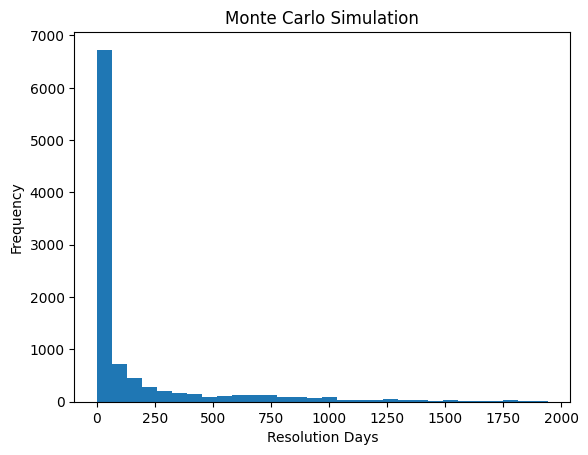

In [5]:
plt.hist(samples, bins=30)

plt.xlabel("Resolution Days")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation")

plt.show()

### Interpretasi Hasil Monte Carlo

Berdasarkan hasil simulasi, sekitar 41% issue memerlukan waktu lebih dari 30 hari untuk diselesaikan. Perbedaan yang cukup jauh antara nilai mean dan median menunjukkan bahwa terdapat beberapa issue yang membutuhkan waktu penyelesaian sangat lama. Akibatnya, distribusi data tidak merata dan cenderung terkonsentrasi pada nilai yang lebih rendah dengan beberapa nilai ekstrem di bagian akhir.

In [6]:
print("Mean:", np.mean(samples))
print("Median:", np.median(samples))
print("Max:", np.max(samples))

Mean: 166.74884
Median: 12.875
Max: 1942.94


## **2. Bloom Filter**

Bloom Filter digunakan untuk mengecek apakah suatu `title` issue kemungkinan sudah pernah muncul sebelumnya. Pada bagian ini, kolom `title` digunakan sebagai item yang dimasukkan ke dalam Bloom Filter.

In [7]:
# 2.1 Bloom Filter Setup

import hashlib

titles = df["title"].dropna().astype(str).tolist()

bit_size = 10000
hash_count = 3
bit_array = [0] * bit_size

def get_hashes(item):
    positions = []
    for i in range(hash_count):
        text = str(i) + item
        hash_value = int(hashlib.md5(text.encode()).hexdigest(), 16)
        positions.append(hash_value % bit_size)
    return positions

print("Jumlah title:", len(titles))

Jumlah title: 6751


In [8]:
# 2.2 Menambahkan Data ke Bloom Filter

for title in titles:
    for position in get_hashes(title):
        bit_array[position] = 1

print("Bloom Filter berhasil dibuat.")
print("Jumlah bit yang terisi:", sum(bit_array))

Bloom Filter berhasil dibuat.
Jumlah bit yang terisi: 8662


In [9]:
# 2.3 Pengecekan Membership

def check_bloom_filter(item):
    for position in get_hashes(item):
        if bit_array[position] == 0:
            return False
    return True
    
test_title = titles[0]

print("Contoh issue:")
print(test_title)
print("Kemungkinan sudah ada di Bloom Filter:", check_bloom_filter(test_title))


Contoh issue:
BUG: Reading csv files with numbers with multiple leading zeros losses a lot of precision
Kemungkinan sudah ada di Bloom Filter: True


### Interpretasi Bloom Filter

Bloom Filter digunakan untuk melakukan pengecekan cepeat apakah suatu issue kemungkinan sudah pernah muncul pada dataset. Pada contoh di atas, issue yand diuji terdeteksi pernah muncul karena sebelumnya sudah dimasukkan ke dalam struktur Bloom Filter. Metode ini efesien untuk mendeteksi duplikasi pada data berukuran besar, meskipun masih memiliki kemungkinan menghasilkan false positive.


## **3. Markov Chain Monte Carlo (MCMC)**

MCMC digunakan untuk menghasilkan sampel secara bertahap berdasarkan sampel sebelumnya. Pada bagian ini, metode MCMC sederhana digunakan untuk melihat pola distribusi waktu penyelesaian issue pada kolom `resolution_days`.

In [10]:
# 3.1 Setup Data MCMC

data = df["resolution_days"].dropna().values

print("Jumlah data:", len(data))
print("Rata-rata data asli", np.mean(data))

Jumlah data: 6751
Rata-rata data asli 162.43417123389128


In [13]:
# 3.2 Menjalankan MCMC

n_iter = 10000

data = df["resolution_days"].dropna().values
data = data[data > 0]

current = np.random.choice(data)
chain = []

for i in range(n_iter):
    proposal = np.random.choice(data)

    accept_prob = min(1, proposal / current)

    if np.random.rand() < accept_prob:
        current = proposal

    chain.append(current)

chain = np.array(chain)

print("Jumlah sampel MCMC:", len(chain))
print("Mean MCMC:", np.mean(chain))
print("Median MCMC:", np.median(chain))
print("Max MCMC:", np.max(chain))

Jumlah sampel MCMC: 10000
Mean MCMC: 822.822625
Median MCMC: 773.86
Max MCMC: 1942.94


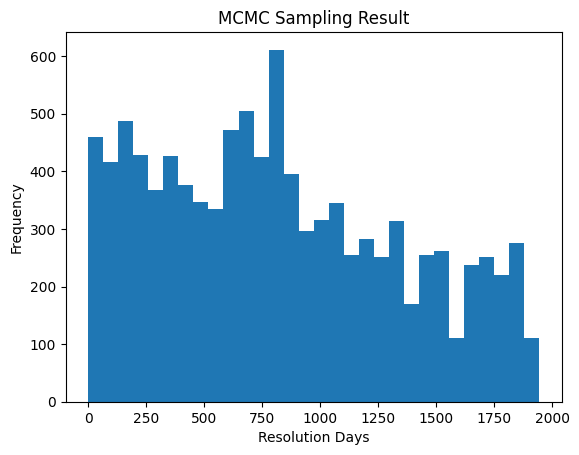

In [14]:
# 3.3 Visualisasi Hasil MCMC

plt.hist(chain, bins=30)

plt.xlabel("Resolution Days")
plt.ylabel("Frequency")
plt.title("MCMC Sampling Result")

plt.show()

### Interpretasi Hasil MCMC

Dari hasil MCMC terlihat bahwa waktu penyelesaian issue memiliki variasi yang cukup besar. Sebagian issue dapat diselesaikan dalam waktu yang lebih singkat, namun terdapat juga issue yang membutuhkan waktu jauh lebih lama hingga mendekati 1900 hari. Hasil ini menunjukkan bahwa proses penyelesaian issue pada dataset tidak merata dan masih terdapat perbedaan yang cukup signifikan antar issue.

---

## Kesimpulan

Berdasarkan hasil simulasi yang telah dilakukan pada dataset issues pandas, diperoleh beberapa temuan sebagai berikut:

- Simulasi Monte Carlo menunjukkan bahwa sekitar 41% issue membutuhkan waktu lebih dari 30 hari untuk diselesaikan.
- Nilai rata-rata waktu penyelesaian issue sebesar 166,75 hari, sedangkan median hanya 12,88 hari. Hal ini menunjukkan adanya beberapa issue dengan waktu penyelesaian yang sangat tinggi.
- Histogram Monte Carlo memperlihatkan distribusi data yang condong ke kanan (right-skewed), sehingga data tidak tersebar secara merata.
- Implementasi Bloom Filter berhasil digunakan untuk melakukan pengecekan keberadaan title issue secara cepat menggunakan mekanisme hashing.
- Hasil MCMC menunjukkan bahwa waktu penyelesaian issue memiliki variasi yang cukup besar, mulai dari issue yang cepat diselesaikan hingga issue yang membutuhkan waktu sangat lama.

Secara keseluruhan, hasil simulasi menunjukkan bahwa proses penyelesaian issue pada proyek pandas memiliki perbedaan waktu yang cukup signifikan antar issue dan masih terdapat beberapa issue yang memerlukan waktu penyelesaian jauh lebih lama dibanding mayoritas issue lainnya.


